In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd

import scarf
from scarf.plotting import FeatureRef

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
rna_run = ds.pipeline.open(label="docs_default")

In [2]:
[adt_layout] = ds.list_artifacts(
    from_assay="ADT",
    kind="embedding",
    operation="run_umap",
    complete_only=True,
)
[adt_clusters] = ds.list_artifacts(
    from_assay="ADT",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    complete_only=True,
)

[snn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "snn"},
    complete_only=True,
)
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)

[snn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": snn_graph},
    complete_only=True,
)
[wnn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)
[snn_clusters] = ds.list_artifacts(
    scope="datastore",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    inputs={"graph": snn_graph},
    complete_only=True,
)
[wnn_clusters] = ds.list_artifacts(
    scope="datastore",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    inputs={"graph": wnn_graph},
    complete_only=True,
)

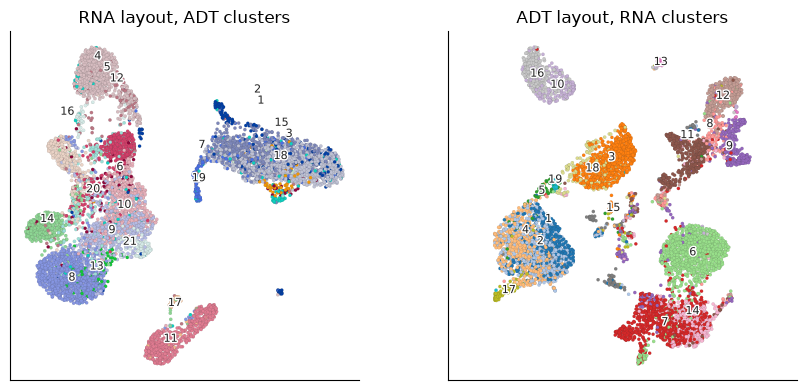

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, layout, labels, title in (
    (axes[0], rna_run["umap"], adt_clusters, "RNA layout, ADT clusters"),
    (axes[1], adt_layout, rna_run["clusters"], "ADT layout, RNA clusters"),
):
    ds.plots.embedding(
        layout=layout,
        color_by=labels,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

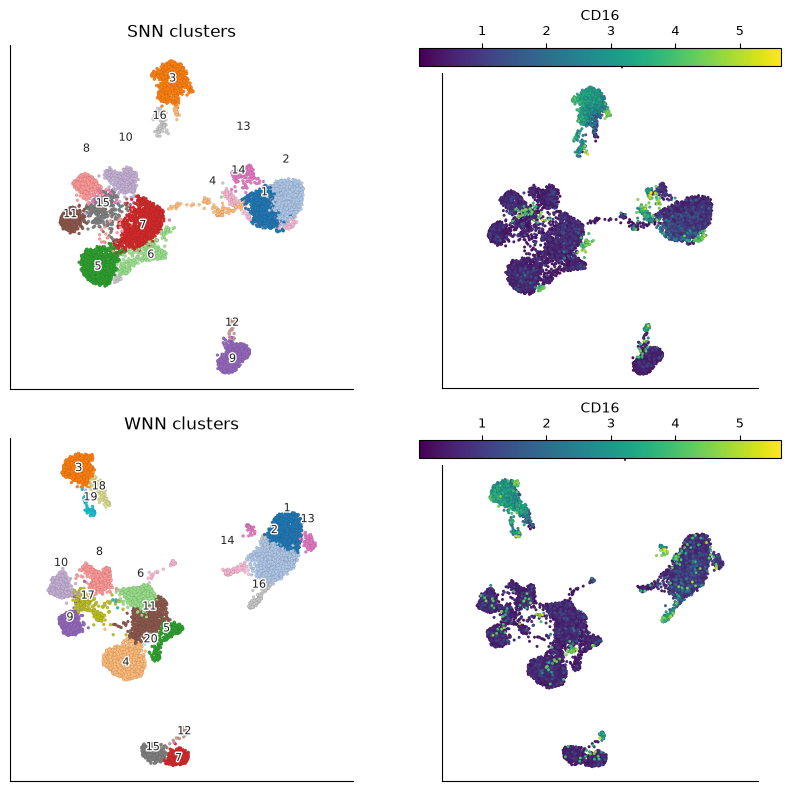

In [4]:
cd16 = FeatureRef("CD16", assay="ADT", by="id", label="CD16")
figure, axes = plt.subplots(2, 2, figsize=(9, 8))
for row, layout, labels, method in (
    (0, snn_layout, snn_clusters, "SNN"),
    (1, wnn_layout, wnn_clusters, "WNN"),
):
    ds.plots.embedding(
        layout=layout,
        color_by=labels,
        legend_loc="on_data",
        show_titles=False,
        target=axes[row, 0],
        show=False,
    )
    axes[row, 0].set_title(f"{method} clusters")
    ds.plots.embedding(
        layout=layout,
        color_by=cd16,
        sort_values=True,
        show_titles=False,
        target=axes[row, 1],
        show=False,
    )
    axes[row, 1].set_title(f"{method}: CD16 protein")
figure.tight_layout()

In [5]:
partitions = {
    "RNA": rna_run["clusters"],
    "ADT": adt_clusters,
    "SNN": snn_clusters,
    "WNN": wnn_clusters,
}
concordance = []
for first, second in combinations(partitions, 2):
    concordance.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": ds.metric_label_concordance(
                partitions[first], partitions[second], metric="ari"
            ),
            "NMI": ds.metric_label_concordance(
                partitions[first], partitions[second], metric="nmi"
            ),
        }
    )
pd.DataFrame(concordance)

,comparison,ARI,NMI
0,RNA vs ADT,0.576373,0.671074
1,RNA vs SNN,0.676909,0.779611
2,RNA vs WNN,0.739431,0.824727
3,ADT vs SNN,0.713908,0.782535
4,ADT vs WNN,0.655779,0.744723
5,SNN vs WNN,0.749559,0.842040


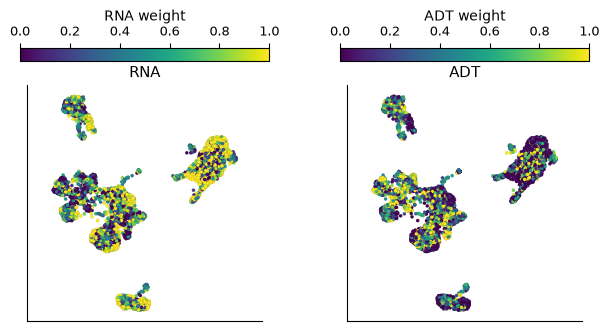

In [6]:
ds.plots.modality_weights(
    graph=wnn_graph,
    layout=wnn_layout,
)